In [1]:
# ScopeSim imports
import scopesim as sim
from scopesim import Simulation, Source
from scopesim.input import UVEXInput

# Other helpful imports
import numpy as np
import matplotlib.pyplot as plt

from synphot import SourceSpectrum, Observation, SpectralElement
from synphot.models import ConstFlux1D, PowerLawFlux1D, BlackBodyNorm1D

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table

In [2]:
# Make a simple input source using a table and the Source object directly
# X and Y positions are in arcsec from the center of the imager field of view
x, y = np.mgrid[0:1:0.01, 0:1:0.01] - 0.5
xpos, ypos = x.flatten() * 3600, y.flatten() * 3600
w = np.ones(xpos.size)

source_spectra = [SourceSpectrum(ConstFlux1D, amplitude=14*u.ABmag), 
                  SourceSpectrum(PowerLawFlux1D, amplitude=0.1, x_0=2000*u.Angstrom, alpha=1.5), 
                  SourceSpectrum(BlackBodyNorm1D, temperature=10000)]
ref = np.zeros(xpos.size) # Distribute spectra references (indices of source_spectra) throughout the sources
ref[4000:7000] = 1
ref[7000:] = 2

source_list = Table(data=[xpos, ypos, w, ref],
                    names=["x", "y", "weight", "ref"],
                    units=[u.arcsec, u.arcsec, None, None])
source_list.meta["photometric_system"] = "ab"
example_source = Source(spectra=source_spectra, table=source_list)
print(example_source)

[0]: Table with 10000 rows, referencing spectra {0, 1, 2}



In [3]:
# Use UVEXInput to make an input source
coordinates = SkyCoord([80.5], [-10.5], unit="deg")
time = Time('2026-10-01 09:00:00')

# Generate some random sky positions around [80.5,-10.5]
n = 10000
rng = np.random.default_rng()
ra = rng.random(n) + 80.
dec = rng.random(n) - 11.

# Generate some spectra and normalize to 0 mag in the bandpass you want to work in (here it's v-band)
# Then scale is defined as 10**(-0.4 * mag) where mag is the desired magnitude in the band you're working in
spectra = {'test': SourceSpectrum(BlackBodyNorm1D, temperature=10000).normalize(0*u.ABmag, band=SpectralElement.from_filter('johnson_v')),
           'test2': SourceSpectrum(BlackBodyNorm1D, temperature=4000).normalize(0*u.ABmag, band=SpectralElement.from_filter('johnson_v'))}
mags = rng.random(n)*4 + 10. # Random magnitudes between 10 and 14
scale = 10**(-0.4 * mags)

# Set which spectrum applies to which sources and create source list table
ref = ['test']*(n//2)
ref2 = ['test2']*(n//2)
ref = ref + ref2
source_list = Table(data=[ra, dec, ref, scale], names=["ra", "dec", "ref", "scale"], units=[u.deg, u.deg, None, None])

# Create the final source object
# UVEXInput takes in the input table, projects source positions onto the UVEX field of view, and adds sky background
i = UVEXInput(coordinates, time, 'nuv', True, point_sources_from_spectra=source_list, spectra=spectra)
example_source2 = i.create_source()

print(example_source2) # Source contains the source table plus sky background images at the location

[0]: Table with 10000 rows, referencing spectra {0, 1}
[1]: ImageHDU with size (3289, 3289), referencing spectrum 2
[2]: ImageHDU with size (3289, 3289), referencing spectrum 3



In [4]:
# Simple Simulation run
simulation = Simulation("UVEX", mode=['fuv']) # Use mode=['nuv'] for an NUV image
hdulist = simulation(example_source)

astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits


 FOVs:   0%|          | 0/49 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

 UVIM Imager PSF Convolution:   0%|          | 0/4096 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - WARNING: Flux is not conserved by UVIM imager PSF convolution: difference is 0.02%


...

 UVIM Imager PSF Convolution:   0%|          | 0/1664 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - WARNING: Flux is not conserved by UVIM imager PSF convolution: difference is 0.01%


 FOV effects:   0%|          | 0/2 [00:00<?, ?it/s]

 UVIM Imager PSF Convolution:   0%|          | 0/416 [00:00<?, ?it/s]

astar.scopesim.effects.psfs - WARNING: Flux is not conserved by UVIM imager PSF convolution: difference is 0.03%
FitsIllumination image-plane shape: (12798, 13098)
FitsIllumination input-map shape: (4096, 4096)
FitsIllumination full focal-plane bounds: (-65.49, 65.49, -63.989999999999995, 63.989999999999995) mm
FitsIllumination sampling full-field map onto current image-plane footprint.
astar.scopesim.detector.detector_manager - Extracting from 9 detectors...
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic.electrons - WARNING: Effect ADConversion: 7739563 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic.electrons - WARNING: Effect ADConversion: 7739563 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic.electrons - WARNING: Effect ADConversion: 7739563 negative pixels
astar.scopesim.effects.electronic.electrons 

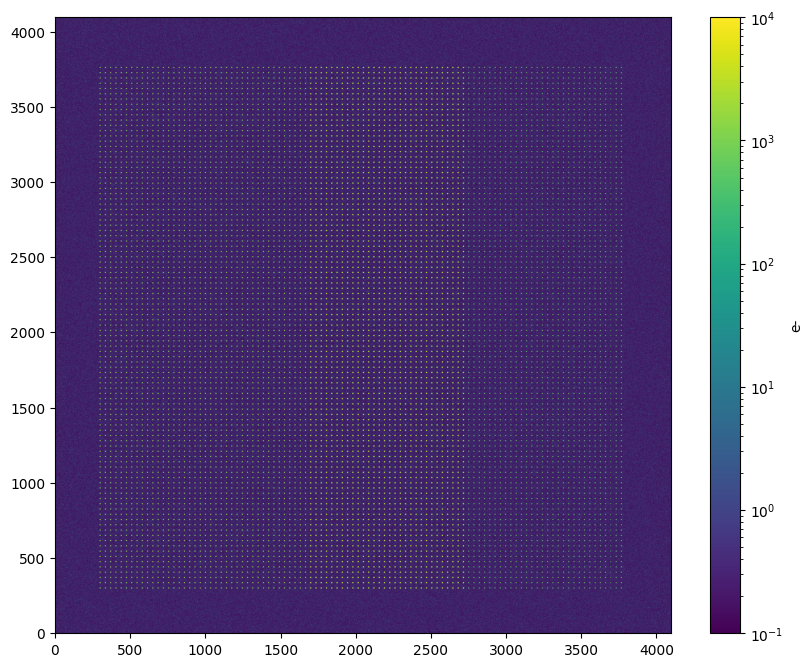

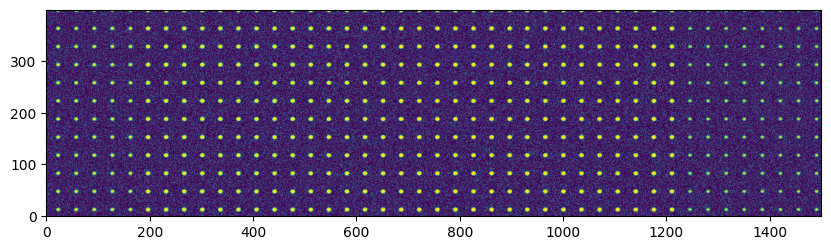

In [5]:
# Plotting and saving results

# Plot the central detector (detector 5) of the first simulation
plt.figure(figsize=(10, 8))
plot_data = hdulist[5].data.copy()
plot_data = np.float64(plot_data) * hdulist[5].header['GAIN'] # Convert to e- units
plot_data[plot_data <= 0] = 1e-2
plt.imshow(plot_data, origin="lower", norm="log", vmin=0.1, vmax=10000)
plt.colorbar(label='e-')
plt.show()

# Zoom in
plt.figure(figsize=(10, 5))
plt.imshow(plot_data[2000:2400,1500:3000], origin="lower", norm="log", vmin=0.1, vmax=10000)
plt.show()

In [6]:
# Running a simulation with configuration parameters changed
# Generate and run a simulation with Distortion off
cmd = sim.UserCommands(use_instrument="UVEX", set_modes=['nuv'])
opt = sim.OpticalTrain(cmd)
om = opt.optics_manager

# Here we can turn certain effects on and off or change some of their parameters
# Turn off sc pointing
om['spacecraft_pointing'].meta['include'] = False

# Set active detectors to a subset
om['UVEX_Detector'].meta['active_detectors'] = [5]

# Turn off the multiwavelength PSF and just use an in-band PSF
om['detector_psf'].meta['include'] = False
om['detector_psf_noredleak'].meta['include'] = True

opt.observe(example_source2, mode='nuv', update=True)
hdulist2 = opt.readout()[0]

astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits


 UVIM Imager PSF Convolution:   0%|          | 0/16384 [00:00<?, ?it/s]

FitsIllumination image-plane shape: (4096, 4096)
FitsIllumination input-map shape: (4096, 4096)
FitsIllumination full focal-plane bounds: (-65.49, 65.49, -63.989999999999995, 63.989999999999995) mm
FitsIllumination sampling full-field map onto current image-plane footprint.
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic.electrons - WARNING: Effect ADConversion: 1649090 negative pixels


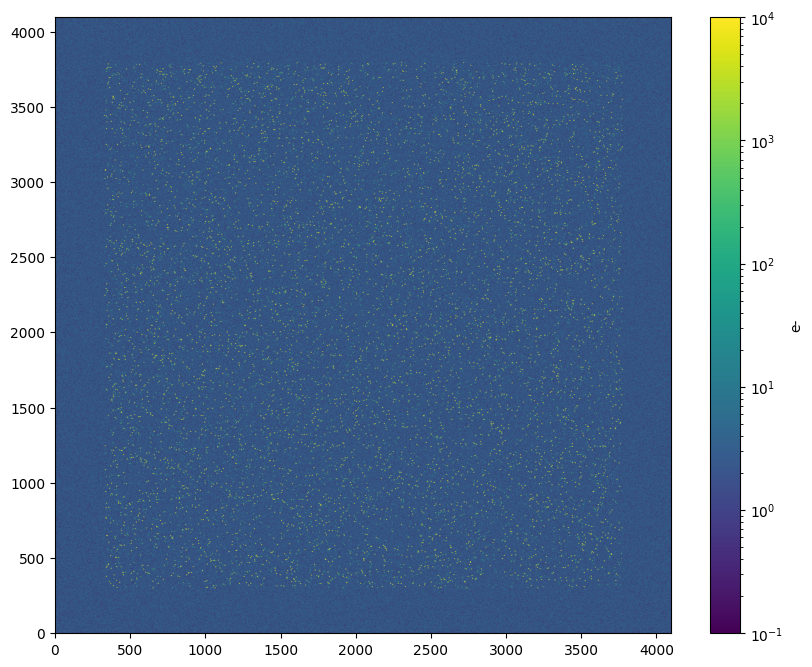

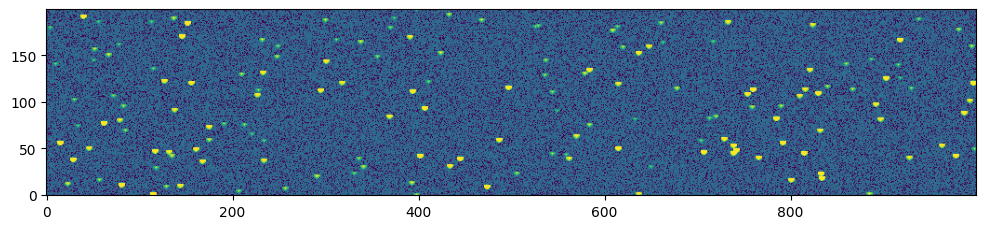

In [7]:
# Plot the first detector of the second simulation (detector 1, even if that's not its ID)
plt.figure(figsize=(10, 8))
plot_data2 = hdulist2[1].data.copy()
plot_data2 = np.float64(plot_data2) * hdulist2[1].header['GAIN'] # Convert to e- units
plot_data2[plot_data2 <= 0] = 1e-2
plt.imshow(plot_data2, origin="lower", norm="log", vmin=0.1, vmax=10000)
plt.colorbar(label='e-')
plt.show()

# Zoom in
plt.figure(figsize=(12, 5))
plt.imshow(plot_data2[2000:2200,1500:2500], origin="lower", norm="log", vmin=0.1, vmax=10000)
plt.show()

In [8]:
# Save outputs as FITS files
hdulist.writeto(f'example_outputs/example_simulation1.fits', overwrite=True)
hdulist2.writeto(f'example_outputs/example_simulation2.fits', overwrite=True)